In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### 1. Load the complete comparison

Run the cells one at a time. `comparison.csv` includes the baseline and all 13 variants, including the rejected case and cases without two complete cycles. Each row is one run; `cycle_mean_cd` and `fixed_window_cd` are the two averaging methods.


In [4]:
from pathlib import Path

path = Path("runs/313_study/results/comparison.csv")
df = pd.read_csv(path)

print(f"Loaded {len(df)} study cases from {path}")
print(df.head())

Loaded 14 study cases from runs/313_study/results/comparison.csv
             case    status manifest_status       kind  \
0    baseline_313  complete        complete   baseline   
1      maxCo_0p25  complete        complete      maxCo   
2         maxCo_1  complete        complete      maxCo   
3  tolerance_x0.1  complete        complete  tolerance   
4   tolerance_x10  complete        complete  tolerance   

                    changed_parameter  baseline_value  \
0                            baseline             NaN   
1                               maxCo             0.5   
2                               maxCo             0.5   
3  p, U, k, omega absolute tolerances             NaN   
4  p, U, k, omega absolute tolerances             NaN   

                 configured_value  configured_L_delta  \
0  {'maxCo': 0.5, 'endTime': 1.0}                 NaN   
1                            0.25                 NaN   
2                             1.0                 NaN   
3              

### 2. Calculate the change relative to the baseline

First, make the case name the row index: `results.loc["maxCo_0p25"]` then selects that run by name.

We calculate each percentage change using the baseline from the **same averaging method**:

$$\Delta C_d\;(\%) = 100\frac{\overline{C_d}_{\mathrm{variant}}-\overline{C_d}_{\mathrm{baseline}}}{\overline{C_d}_{\mathrm{baseline}}}.$$

A negative value means lower mean drag. Missing Cd values remain missing; they are not replaced by zero.


In [5]:
results = df.set_index("case")

baseline_cycle_cd = results.loc["baseline_313", "cycle_mean_cd"]
baseline_fixed_cd = results.loc["baseline_313", "fixed_window_cd"]

results["Delta Cd cycles (%)"] = 100 * (results["cycle_mean_cd"] - baseline_cycle_cd) / baseline_cycle_cd
results["Delta Cd fixed (%)"] = 100 * (results["fixed_window_cd"] - baseline_fixed_cd) / baseline_fixed_cd

print(f"Baseline two-cycle Cd: {baseline_cycle_cd:.6f}")
print(f"Baseline fixed-window Cd: {baseline_fixed_cd:.6f}")
print(results.loc["maxCo_0p25", ["cycle_mean_cd", "Delta Cd cycles (%)"]])


Baseline two-cycle Cd: 2.162301
Baseline fixed-window Cd: 2.131767
cycle_mean_cd          2.149296
Delta Cd cycles (%)   -0.601425
Name: maxCo_0p25, dtype: object


### 3. Arrange the numerical parameters in your table layout

Each tuple below gives the parameter name, baseline value, lower value and its case name, then higher value and its case name. The loop looks up the calculated changes and makes one table row.

The tolerance row uses a multiplier: baseline absolute tolerances are `p = 1e-7` and `U/k/omega = 1e-8`. Their `relTol` values were unchanged. There was no lower PIMPLE run, so its two lower entries are blank. These results all use **two complete lift cycles after 0.5 s**.


In [6]:
columns = ["Parameter", "Old value", "New lower value", "Delta Cd lower (%)", "New higher value", "Delta Cd higher (%)"]

numerical_cases = [
    ("Linear tolerance multiplier", 1, 0.1, "tolerance_x0.1", 10, "tolerance_x10"),
    ("Maximum Courant number", 0.5, 0.25, "maxCo_0p25", 1.0, "maxCo_1"),
    ("Inlet turbulence intensity", "5%", "1%", "turbulenceIntensity_1pct", "10%", "turbulenceIntensity_10pct"),
    ("PIMPLE outer correctors", 2, "---", None, 4, "outerCorrectors_4"),
]

rows = []
for parameter, old, lower, lower_case, higher, higher_case in numerical_cases:
    lower_delta = results.loc[lower_case, "Delta Cd cycles (%)"] if lower_case is not None else np.nan
    higher_delta = results.loc[higher_case, "Delta Cd cycles (%)"]
    rows.append([parameter, old, lower, lower_delta, higher, higher_delta])

numerical_table = pd.DataFrame(rows, columns=columns)
print(numerical_table.round(3).to_string(index=False, na_rep="---"))


                  Parameter Old value New lower value  Delta Cd lower (%) New higher value  Delta Cd higher (%)
Linear tolerance multiplier         1             0.1               0.001               10                0.001
     Maximum Courant number       0.5            0.25              -0.601              1.0                0.072
 Inlet turbulence intensity        5%              1%               0.149              10%               -0.011
    PIMPLE outer correctors         2             ---                 ---                4               -0.057


### 4. Find the last two complete lift cycles for each domain run

We read the original coefficient files. Columns 0, 1 and 4 contain time, Cd and Cl. A cycle runs between two consecutive **rising Cl = 0 crossings**, with crossing times interpolated between saved samples.

Take the **last three crossings anywhere in the file**, without the 0.5 s restriction. These bound the last two complete cycles; an unfinished cycle at the end is excluded. Each run can have different bounds.

Insert the exact start/end times, interpolate Cd there, integrate with `np.trapezoid`, then divide by the full two-cycle duration. This is a time-weighted combined mean, rather than an equally weighted average of two cycle means. Apply the same method to the baseline.


In [ ]:
def last_two_cycles_mean(coefficient_file):
    time, cd, cl = np.loadtxt(coefficient_file, usecols=(0, 1, 4), unpack=True)

    # Locate samples on either side of a rising lift zero crossing.
    crossing_indices = np.where((cl[:-1] < 0) & (cl[1:] >= 0))[0]
    crossing_times = time[crossing_indices] - cl[crossing_indices] * (
        time[crossing_indices + 1] - time[crossing_indices]
    ) / (cl[crossing_indices + 1] - cl[crossing_indices])

    if len(crossing_times) < 3:
        raise ValueError(f"Fewer than two complete lift cycles in {coefficient_file}")
    start, middle, end = crossing_times[-3:]

    # Include the exact crossing times, not just the nearby saved samples.
    inside = (time > start) & (time < end)
    cycle_time = np.r_[start, time[inside], end]
    cycle_cd = np.interp(cycle_time, time, cd)
    average_cd = np.trapezoid(cycle_cd, cycle_time) / (end - start)
    return start, middle, end, average_cd


### 5. Inspect the cycle bounds and calculate percentage changes

The printed table below shows the actual interval used in each file. The shorter-inlet raw mean is calculated for inspection, but its mesh failure still excludes it from the accepted comparison.

The domain percentages use the **same saved baseline Cd as the numerical table above**, `baseline_cycle_cd = 2.1623008`. We do not replace that reference when changing how the domain runs are averaged. Numerical-parameter results above keep their existing averaging method.


In [ ]:
domain_names = results.index[results["kind"] == "domain"].tolist()
cycle_rows = []

for case_name in ["baseline_313"] + domain_names:
    if case_name == "baseline_313":
        case_directory = Path("saved_runs/313_pimple_run")
        mesh_accepted = True
    else:
        case_directory = Path("runs/313_study") / case_name
        mesh_accepted = results.loc[case_name, "status"] == "complete"

    coefficient_file = next(case_directory.glob("postProcessing/forceCoeffs1/*/coefficient.dat"))
    start, middle, end, average_cd = last_two_cycles_mean(coefficient_file)
    cycle_rows.append([case_name, start, middle, end, end - start, average_cd, mesh_accepted])

domain_cycle_results = pd.DataFrame(
    cycle_rows,
    columns=["case", "Window start (s)", "Cycle 1 end (s)", "Window end (s)", "Duration (s)", "Last-two-cycle Cd", "Mesh accepted"],
).set_index("case")

reference_cd = baseline_cycle_cd
domain_cycle_results["Delta Cd last two cycles (%)"] = 100 * (
    domain_cycle_results["Last-two-cycle Cd"] - reference_cd
) / reference_cd
# Preserve the raw mean, but exclude the failed mesh from reported changes.
domain_cycle_results.loc[~domain_cycle_results["Mesh accepted"], "Delta Cd last two cycles (%)"] = np.nan

print(f"Reference baseline Cd: {reference_cd:.6f}")


### 6. Print the domain sensitivity table

All domain changes below use the last two complete cycles relative to the saved baseline used in the numerical table, without a minimum start time. Distances use the configured `L = 1.09585 m`; inlet distance is positive upstream of the origin, while outlet and roof coordinates are measured from the origin.

The refinement box and levels stayed fixed. The shorter-inlet change remains **Rejected** for mesh quality.

The printed table retains the earlier six-column layout: parameter, old value, lower value and percentage change, higher value and percentage change. Cycle boundaries remain available in `domain_cycle_results` if you want to inspect them.


In [ ]:
domain_cases = [
    ("Inlet distance (L)", 5, 4, "upstream_dist_minus_1L", 6, "upstream_dist_plus_1L"),
    ("Outlet coordinate (L)", 11, 10, "downstream_dist_minus_1L", 12, "downstream_dist_plus_1L"),
    ("Roof coordinate (L)", 6, 5, "roof_height_minus_1L", 7, "roof_height_plus_1L"),
]

rows = []
for parameter, old, lower, lower_case, higher, higher_case in domain_cases:
    lower_delta = domain_cycle_results.loc[lower_case, "Delta Cd last two cycles (%)"]
    higher_delta = domain_cycle_results.loc[higher_case, "Delta Cd last two cycles (%)"]
    rows.append([parameter, old, lower, lower_delta, higher, higher_delta])

domain_table = pd.DataFrame(rows, columns=columns)
print(domain_table.round(3).to_string(index=False, na_rep="Rejected"))


When discussing these tables, retain the sampling limitation: the baseline's two cycle means differ by 5.274%, and its two half-window means differ by 7.213%. Small sensitivity differences alone do not establish statistical stationarity.


### 7. Compare the expanded refinement box for 313

This additional run expands each x/y side of the refinement box outward by `1L`, with z unchanged. The original x/y bounds are `[-L, 4L]` and `[-L, 2L]`; the new bounds are `[-2L, 5L]` and `[-2L, 3L]`, where `L = 1.09585 m`.

All other snappyHexMesh settings, the outer domain, and the solver settings retain their saved 313 baseline values, including `maxCo = 0.5`.

The saved result uses the **last two complete lift cycles anywhere in the file**, with time-weighted integration. The percentage change below uses the same `baseline_cycle_cd` as the earlier tables. The final table below combines the domain results and this refinement-box result in the same six-column layout. Refinement-box expansion is `0L` for the original box and `1L` outward on each x/y side for the new box; no lower case was run. No separate file is exported.


In [ ]:
import json

refinement_result_path = Path("runs/313_refinement_check/result.json")

if refinement_result_path.exists():
    refinement_result = json.loads(refinement_result_path.read_text())
    refinement_cd = refinement_result.get("combined", {}).get("two_cycle_cd")
    refinement_delta = np.nan
    if refinement_result["accepted"] and refinement_cd is not None:
        refinement_delta = 100 * (refinement_cd - baseline_cycle_cd) / baseline_cycle_cd

    refinement_table = pd.DataFrame(
        [["Refinement-box expansion (L)", 0, "---", np.nan, 1, refinement_delta]],
        columns=columns,
    )
    print(f"Reference baseline Cd: {baseline_cycle_cd:.6f}")
    print(f"Expanded-box last-two-cycle Cd: {refinement_cd}")
    domain_refinement_table = pd.concat(
        [domain_table.round(3).fillna("Rejected"), refinement_table.round(3)],
        ignore_index=True,
    )
    print(domain_refinement_table.to_string(index=False, na_rep="---"))
    if not refinement_result["accepted"]:
        print("The refinement-box case failed its solver or mesh checks; its change is excluded.")
    elif refinement_cd is None:
        print("Fewer than two complete lift cycles were found; no cycle-based change is reported.")
else:
    print("The 313 refinement-box run has not finished yet.")


Reference baseline Cd: 2.162301
Expanded-box last-two-cycle Cd: 2.1144296671530443
                   Parameter  Old value New lower value Delta Cd lower (%)  New higher value  Delta Cd higher (%)
          Inlet distance (L)          5               4           Rejected                 6               -2.462
       Outlet coordinate (L)         11              10             -2.622                12              -12.267
         Roof coordinate (L)          6               5            -12.826                 7               -9.578
Refinement-box expansion (L)          0             ---                ---                 1               -2.214


### 8. Compare original and expanded prism Cd over time

Overlay the raw Cd histories from the saved original prism run and the combined expanded prism run. The expanded run changed the inlet, outlet, roof, refinement box and maximum Courant number together; z remained unchanged.

The upper plot includes the large startup spike. The lower plot shows the same histories from 0.05 s onward so the later behaviour is visible. The original trace is drawn on top of the expanded trace.


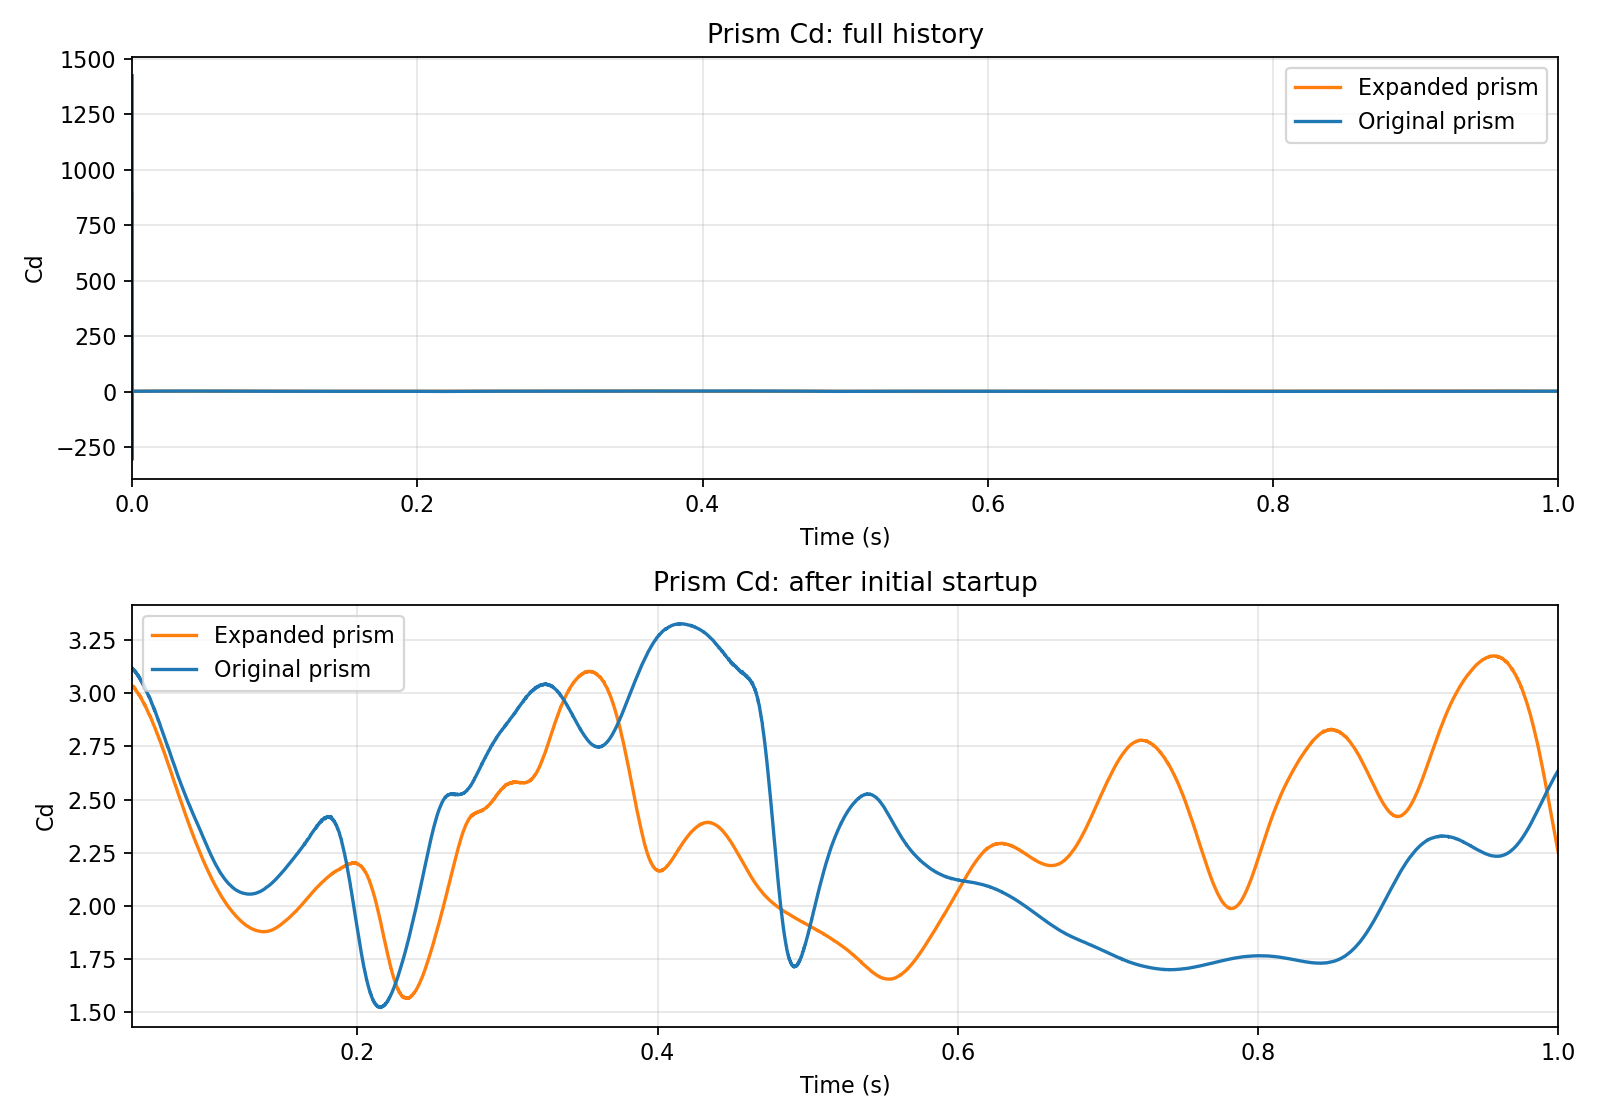

In [ ]:
prism_time, prism_cd = np.loadtxt(
    Path("saved_runs/prism_pimple_run/postProcessing/forceCoeffs1/0/coefficient.dat"),
    usecols=(0, 1), unpack=True,
)
expanded_time, expanded_cd = np.loadtxt(
    Path("runs/prism_combined_check/case/postProcessing/forceCoeffs1/0/coefficient.dat"),
    usecols=(0, 1), unpack=True,
)

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
for ax, start in zip(axes, [0, 0.05]):
    expanded_mask = expanded_time >= start
    prism_mask = prism_time >= start
    ax.plot(expanded_time[expanded_mask], expanded_cd[expanded_mask],
            label="Expanded prism", color="tab:orange")
    ax.plot(prism_time[prism_mask], prism_cd[prism_mask],
            label="Original prism", color="tab:blue")
    ax.set_xlim(start, 1)
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Cd")
    ax.grid(alpha=0.3)
    ax.legend()

axes[0].set_title("Prism Cd: full history")
axes[1].set_title("Prism Cd: after initial startup")
fig.tight_layout()
plt.show()
